# 05b - Comprehensive Class Imbalance Strategy Evaluation

## Objective
Systematically compare 7 balancing strategies across 3 models (XGBoost, SVM, Random Forest) using rigorous evaluation metrics and statistical testing.

## Balancing Strategies Tested
1. **Baseline (Raw Unbalanced)** - No balancing
2. **Random UnderSampling (RUS)** - Multiple ratios: 0.5, 0.7, 0.8, 1.0
3. **Random OverSampling (ROS)** - Simple duplication
4. **SMOTE** - Synthetic Minority Oversampling (k=3, 5, 7)
5. **ADASYN** - Adaptive Synthetic Sampling
6. **Class Weight** - Native model support (SVM, RF)
7. **Scale_Pos_Weight** - XGBoost-specific weighting

## Evaluation Metrics
- **Balanced Accuracy** (Primary)
- **F1 Score** (Grinder class)
- **PR-AUC** (Precision-Recall curve)
- **MCC** (Matthews Correlation Coefficient)
- **Precision, Recall, Specificity**
- **Training Time**

---
## Section 1: Setup and Imports

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, precision_score, 
    recall_score, matthews_corrcoef, average_precision_score,
    confusion_matrix, classification_report
)

# Imbalanced-learn
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler

# Models
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Statistical testing
from scipy.stats import wilcoxon

# MLflow (optional)
try:
    import mlflow
    import mlflow.sklearn
    import mlflow.xgboost
    MLFLOW_AVAILABLE = True
except ImportError:
    MLFLOW_AVAILABLE = False
    print("MLflow not available - results will be saved to CSV only")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 4)

print("✓ All imports successful")
print(f"✓ Random seed set to {RANDOM_STATE}")
print(f"✓ MLflow available: {MLFLOW_AVAILABLE}")

✓ All imports successful
✓ Random seed set to 42
✓ MLflow available: True


---
## Section 2: Configuration

In [2]:
# Experiment configuration
CONFIG = {
    'random_state': RANDOM_STATE,
    'n_folds': 5,
    'feat_sets': ['mfcc', 'gtcc', 'combined'],  # Test all feature sets
    'test_size': 0.3,
    'val_split': 0.15,  # From remaining training data
}

# Paths
PATHS = {
    'features': Path('../data/features/classical'),
    'results': Path('../results/balancing_comparison'),
    'models': Path('../models/balancing_comparison'),
}

# Create directories if they don't exist
for path in PATHS.values():
    path.mkdir(parents=True, exist_ok=True)

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print("\nPaths created:")
for key, value in PATHS.items():
    print(f"  {key}: {value}")

Configuration:
  random_state: 42
  n_folds: 5
  feat_sets: ['mfcc', 'gtcc', 'combined']
  test_size: 0.3
  val_split: 0.15

Paths created:
  features: ../data/features/classical
  results: ../results/balancing_comparison
  models: ../models/balancing_comparison


---
## Section 3: Define Balancing Strategies

In [3]:
def get_balancing_strategies():
    """
    Returns dictionary of all balancing strategies to test.
    Key: strategy name, Value: imblearn sampler object or None
    """
    strategies = {
        # Baseline
        'raw': None,
        
        # Random UnderSampling (various ratios)
        'rus_0.5': RandomUnderSampler(sampling_strategy=0.5, random_state=RANDOM_STATE),
        'rus_0.7': RandomUnderSampler(sampling_strategy=0.7, random_state=RANDOM_STATE),
        'rus_0.8': RandomUnderSampler(sampling_strategy=0.8, random_state=RANDOM_STATE),
        'rus_1.0': RandomUnderSampler(sampling_strategy=1.0, random_state=RANDOM_STATE),
        
        # Random OverSampling
        'ros': RandomOverSampler(sampling_strategy=1.0, random_state=RANDOM_STATE),
        
        # SMOTE (various k_neighbors)
        'smote_k3': SMOTE(sampling_strategy=1.0, k_neighbors=3, random_state=RANDOM_STATE),
        'smote_k5': SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=RANDOM_STATE),
        'smote_k7': SMOTE(sampling_strategy=1.0, k_neighbors=7, random_state=RANDOM_STATE),
        
        # ADASYN
        'adasyn': ADASYN(sampling_strategy=1.0, n_neighbors=5, random_state=RANDOM_STATE),
    }
    
    return strategies

# Display strategies
strategies = get_balancing_strategies()
print(f"Total balancing strategies defined: {len(strategies)}")
print("\nStrategies:")
for i, (name, strategy) in enumerate(strategies.items(), 1):
    strategy_type = type(strategy).__name__ if strategy else "None (Raw)"
    print(f"  {i}. {name:15s} -> {strategy_type}")

Total balancing strategies defined: 10

Strategies:
  1. raw             -> None (Raw)
  2. rus_0.5         -> RandomUnderSampler
  3. rus_0.7         -> RandomUnderSampler
  4. rus_0.8         -> RandomUnderSampler
  5. rus_1.0         -> RandomUnderSampler
  6. ros             -> RandomOverSampler
  7. smote_k3        -> SMOTE
  8. smote_k5        -> SMOTE
  9. smote_k7        -> SMOTE
  10. adasyn          -> ADASYN


---
## Section 4: Define Models with Class Weight Variants

In [4]:

def get_models(y_train=None):
    """
    Returns dictionary of all model configurations to test.
    Includes variants with and without class_weight/scale_pos_weight.
    
    Args:
        y_train: Training labels (needed to calculate scale_pos_weight)
    """
    models = {}
    
    # Calculate scale_pos_weight if y_train provided
    if y_train is not None:
        n_neg = np.sum(y_train == 0)
        n_pos = np.sum(y_train == 1)
        scale_pos_auto = n_neg / n_pos if n_pos > 0 else 1.0
        print(f"Calculated scale_pos_weight: {scale_pos_auto:.3f} (neg={n_neg}, pos={n_pos})")
    else:
        scale_pos_auto = 2.5  # Default placeholder
    
    # XGBoost variants
    models['xgb_raw'] = XGBClassifier(
        random_state=RANDOM_STATE, 
        use_label_encoder=False,
        eval_metric='logloss'
    )
    
    models['xgb_scale_1.5'] = XGBClassifier(
        scale_pos_weight=1.5,
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    
    models['xgb_scale_2.0'] = XGBClassifier(
        scale_pos_weight=2.0,
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    
    models['xgb_scale_2.5'] = XGBClassifier(
        scale_pos_weight=2.5,
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    
    models['xgb_scale_auto'] = XGBClassifier(
        scale_pos_weight=scale_pos_auto,
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    
    # SVM variants
    from sklearn.svm import LinearSVC
    from sklearn.calibration import CalibratedClassifierCV

    
    models['svm_raw'] = CalibratedClassifierCV(
        LinearSVC(
            random_state=RANDOM_STATE,
            max_iter=2000,
            dual='auto'  # Automatically choose solver
        ),
        cv=3  # Use 3-fold CV for probability calibration
    )

    models['svm_balanced'] = CalibratedClassifierCV(
        LinearSVC(
            class_weight='balanced',
            random_state=RANDOM_STATE,
            max_iter=2000,
            dual='auto'
        ),
        cv=3
)

    
    # Random Forest variants
    models['rf_raw'] = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100
        n_jobs=-1
    )
    
    models['rf_balanced'] = RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_estimators=100
        n_jobs=-1
    )
    
    return models

# Display models (without y_train for now)
models = get_models()
print(f"\nTotal model configurations: {len(models)}")
print("\nModel configurations:")
for i, (name, model) in enumerate(models.items(), 1):
    model_type = type(model).__name__
    print(f"  {i}. {name:20s} -> {model_type}")


Total model configurations: 9

Model configurations:
  1. xgb_raw              -> XGBClassifier
  2. xgb_scale_1.5        -> XGBClassifier
  3. xgb_scale_2.0        -> XGBClassifier
  4. xgb_scale_2.5        -> XGBClassifier
  5. xgb_scale_auto       -> XGBClassifier
  6. svm_raw              -> CalibratedClassifierCV
  7. svm_balanced         -> CalibratedClassifierCV
  8. rf_raw               -> RandomForestClassifier
  9. rf_balanced          -> RandomForestClassifier


---
## Section 5: Evaluation Function with Cross-Validation

In [5]:
def evaluate_strategy(model, X, y, balancing_method, cv_strategy, verbose=True):
    """
    Evaluate a model with a specific balancing strategy using stratified k-fold CV.
    
    Args:
        model: Sklearn/XGBoost classifier
        X: Feature matrix (numpy array)
        y: Labels (numpy array)
        balancing_method: imblearn sampler or None
        cv_strategy: StratifiedKFold object
        verbose: Print fold-by-fold results
        
    Returns:
        Dictionary with mean, std, and raw values for all metrics
    """
    fold_metrics = {
        'balanced_acc': [],
        'f1': [],
        'precision': [],
        'recall': [],
        'specificity': [],
        'mcc': [],
        'pr_auc': [],
        'training_time': [],
        'samples_after_balancing': []
    }
    
    for fold_idx, (train_idx, val_idx) in enumerate(cv_strategy.split(X, y), 1):
        # Split data
        X_train_fold = X[train_idx]
        y_train_fold = y[train_idx]
        X_val_fold = X[val_idx]
        y_val_fold = y[val_idx]
        
        # Apply balancing (if not None)
        if balancing_method is not None:
            try:
                X_train_balanced, y_train_balanced = balancing_method.fit_resample(
                    X_train_fold, y_train_fold
                )
            except Exception as e:
                if verbose:
                    print(f"    Warning: Balancing failed for fold {fold_idx}: {e}")
                    print(f"    Using unbalanced data instead.")
                X_train_balanced = X_train_fold
                y_train_balanced = y_train_fold
        else:
            X_train_balanced = X_train_fold
            y_train_balanced = y_train_fold
        
        fold_metrics['samples_after_balancing'].append(len(y_train_balanced))
        
        # Train model
        start_time = time.time()
        model.fit(X_train_balanced, y_train_balanced)
        training_time = time.time() - start_time
        fold_metrics['training_time'].append(training_time)
        
        # Predict on validation set (original distribution)
        y_pred = model.predict(X_val_fold)
        y_proba = model.predict_proba(X_val_fold)[:, 1]
        
        # Calculate metrics
        fold_metrics['balanced_acc'].append(balanced_accuracy_score(y_val_fold, y_pred))
        fold_metrics['f1'].append(f1_score(y_val_fold, y_pred, pos_label=1, zero_division=0))
        fold_metrics['precision'].append(precision_score(y_val_fold, y_pred, pos_label=1, zero_division=0))
        fold_metrics['recall'].append(recall_score(y_val_fold, y_pred, pos_label=1, zero_division=0))
        
        # Specificity (TN / (TN + FP))
        tn = np.sum((y_pred == 0) & (y_val_fold == 0))
        fp = np.sum((y_pred == 1) & (y_val_fold == 0))
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        fold_metrics['specificity'].append(specificity)
        
        fold_metrics['mcc'].append(matthews_corrcoef(y_val_fold, y_pred))
        fold_metrics['pr_auc'].append(average_precision_score(y_val_fold, y_proba))
        
        if verbose:
            print(f"    Fold {fold_idx}: Bal_Acc={fold_metrics['balanced_acc'][-1]:.4f}, "
                  f"F1={fold_metrics['f1'][-1]:.4f}, "
                  f"Recall={fold_metrics['recall'][-1]:.4f}, "
                  f"Time={training_time:.2f}s")
    
    # Calculate summary statistics
    results = {}
    for metric, values in fold_metrics.items():
        results[f'{metric}_mean'] = np.mean(values)
        results[f'{metric}_std'] = np.std(values)
        results[f'{metric}_values'] = values  # Store for statistical testing
    
    return results

print("✓ Evaluation function defined")

✓ Evaluation function defined


In [6]:
def handle_nan_in_features(X, y, strategy='remove', verbose=True):
    """Handle NaN values in feature matrix before training."""
    # Check for NaN/Inf values
    nan_mask = ~np.isfinite(X).all(axis=1)
    n_nan_samples = np.sum(nan_mask)
    n_total_samples = len(X)
    
    nan_per_feature = np.sum(~np.isfinite(X), axis=0)
    nan_features_idx = np.where(nan_per_feature > 0)[0]
    
    nan_info = {
        'n_nan_samples': n_nan_samples,
        'percent_nan_samples': 100 * n_nan_samples / n_total_samples if n_total_samples > 0 else 0,
    }
    
    if verbose:
        print(f"\n{'='*80}\nNaN/Inf Detection\n{'='*80}")
        print(f"Total samples: {n_total_samples}")
        print(f"Samples with NaN/Inf: {n_nan_samples} ({nan_info['percent_nan_samples']:.2f}%)")
        if n_nan_samples > 0:
            print(f"Features with NaN: {len(nan_features_idx)}")
    
    if n_nan_samples == 0:
        if verbose:
            print("\n✓ No NaN/Inf values - data is clean!\n" + "="*80 + "\n")
        return X, y, nan_info
    
    if strategy == 'remove':
        clean_mask = ~nan_mask
        X_clean = X[clean_mask]
        y_clean = y[clean_mask] if y is not None else None
        
        if verbose:
            print(f"\nStrategy: REMOVE")
            print(f"  Removed: {n_nan_samples} samples")
            print(f"  Remaining: {len(X_clean)} samples")
            if y_clean is not None:
                print(f"  New class distribution: {np.bincount(y_clean)}")
            print(f"\n✓ Cleaning successful\n{'='*80}\n")
        
    elif strategy == 'impute':
        X_clean = X.copy()
        for feat_idx in nan_features_idx:
            col = X_clean[:, feat_idx]
            finite_mask = np.isfinite(col)
            if np.sum(finite_mask) > 0:
                X_clean[~finite_mask, feat_idx] = np.median(col[finite_mask])
            else:
                X_clean[:, feat_idx] = 0
        y_clean = y
        
        if verbose:
            print(f"\nStrategy: IMPUTE with median")
            print(f"  Imputed {len(nan_features_idx)} features")
            print(f"\n✓ Cleaning successful\n{'='*80}\n")
    
    return X_clean, y_clean, nan_info

print("✓ NaN handling function defined")


✓ NaN handling function defined


---
## Section 6: Main Experiment Runner

In [7]:
def run_experiment(feat_set='mfcc', use_mlflow=False):
    """
    Run comprehensive balancing strategy comparison for a given feature set.
    
    Args:
        feat_set: Feature set name ('mfcc', 'gtcc', or 'combined')
        use_mlflow: Whether to log results to MLflow
        
    Returns:
        DataFrame with all results
    """
    print(f"\n{'='*80}")
    print(f"Running Experiment: {feat_set.upper()}")
    print(f"{'='*80}\n")
    
    # Load features
    feature_path = PATHS['features'] / f'{feat_set}_unbalanced_features.npy'
    label_path = PATHS['features'] / 'labels.npy'
    
    if not feature_path.exists() or not label_path.exists():
        print(f"ERROR: Feature files not found at:")
        print(f"  {feature_path}")
        print(f"  {label_path}")
        return None
    
    X = np.load(feature_path)
    y = np.load(label_path)
    
    print(f"Loaded features: {X.shape}")
    print(f"Class distribution: {np.bincount(y)} (0=Non-grinder, 1=Grinder)")
    print(f"Imbalance ratio: {np.sum(y==0) / np.sum(y==1):.2f}:1\n")
    
        # *** ADD THIS BLOCK ***
    print("Checking for NaN/Inf values...")
    X, y, nan_info = handle_nan_in_features(X, y, strategy='remove', verbose=True)

    if X is None or len(X) == 0:
        print("ERROR: No valid samples after NaN handling")
        return None
    # *** END NEW BLOCK ***

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
        
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print("✓ Features standardized\n")
    
    # Initialize CV strategy
    cv_strategy = StratifiedKFold(
        n_splits=CONFIG['n_folds'],
        shuffle=True,
        random_state=RANDOM_STATE
    )
    print(f"✓ Using {CONFIG['n_folds']}-fold Stratified CV\n")
    
    # Get strategies and models
    balancing_strategies = get_balancing_strategies()
    models = get_models(y_train=y)  # Pass y to calculate scale_pos_weight
    
    # Initialize MLflow if requested
    if use_mlflow and MLFLOW_AVAILABLE:
        mlflow.set_experiment(f"balancing_comparison_{feat_set}")
        print("✓ MLflow experiment set\n")
    
    # Storage for results
    all_results = []
    total_experiments = 0
    
    # Count total experiments
    for model_name in models.keys():
        if 'balanced' in model_name or 'scale' in model_name:
            total_experiments += 1  # Only test with raw data
        else:
            total_experiments += len(balancing_strategies)
    
    print(f"Total experiments to run: {total_experiments}\n")
    print("-" * 80)
    
    experiment_counter = 0
    
    # Run experiments
    for model_name, model in models.items():
        model_type = model_name.split('_')[0]  # xgb, svm, rf
        
        # Determine compatible balancing strategies
        if 'balanced' in model_name or 'scale' in model_name:
            # Class_weight/scale_pos_weight models - only test with 'raw' data
            compatible_strategies = ['raw']
        else:
            # Models without class weighting - test all balancing strategies
            compatible_strategies = list(balancing_strategies.keys())
        
        for strategy_name in compatible_strategies:
            experiment_counter += 1
            balancing_method = balancing_strategies[strategy_name]
            
            print(f"\n[{experiment_counter}/{total_experiments}] Testing: {model_name} + {strategy_name}")
            
            try:
                # Start MLflow run if enabled
                if use_mlflow and MLFLOW_AVAILABLE:
                    with mlflow.start_run(run_name=f"{feat_set}_{model_name}_{strategy_name}"):
                        # Evaluate
                        results = evaluate_strategy(
                            model, X_scaled, y,
                            balancing_method, cv_strategy,
                            verbose=False
                        )
                        
                        # Log to MLflow
                        mlflow.log_params({
                            'model': model_name,
                            'balancing': strategy_name,
                            'feat_set': feat_set,
                            'n_folds': CONFIG['n_folds']
                        })
                        mlflow.log_metrics({
                            'balanced_acc': results['balanced_acc_mean'],
                            'f1': results['f1_mean'],
                            'recall': results['recall_mean'],
                            'precision': results['precision_mean'],
                            'mcc': results['mcc_mean'],
                            'training_time': results['training_time_mean']
                        })
                else:
                    # Evaluate without MLflow
                    results = evaluate_strategy(
                        model, X_scaled, y,
                        balancing_method, cv_strategy,
                        verbose=False
                    )
                
                # Add metadata
                results['model'] = model_name
                results['balancing'] = strategy_name
                results['feat_set'] = feat_set
                
                # Print summary
                print(f"  Results: Bal_Acc={results['balanced_acc_mean']:.4f} ± {results['balanced_acc_std']:.4f}, "
                      f"F1={results['f1_mean']:.4f} ± {results['f1_std']:.4f}, "
                      f"Recall={results['recall_mean']:.4f}, "
                      f"Time={results['training_time_mean']:.2f}s")
                
                all_results.append(results)
                
            except Exception as e:
                print(f"  ERROR: {str(e)}")
                continue
    
    print("\n" + "="*80)
    print("Experiment Complete!")
    print("="*80 + "\n")
    
    # Convert to DataFrame
    results_df = pd.DataFrame(all_results)
    
    # Save to CSV
    output_file = PATHS['results'] / f'balancing_comparison_{feat_set}.csv'
    results_df.to_csv(output_file, index=False)
    print(f"✓ Results saved to: {output_file}\n")
    
    return results_df

print("✓ Experiment runner defined")

✓ Experiment runner defined


---
## Section 7: Results Analysis Functions

In [18]:
def create_comparison_table(results_df, metric='balanced_acc_mean', top_n=10):
    """
    Create a comparison table showing performance across strategies.
    
    Args:
        results_df: DataFrame with all results
        metric: Metric to compare
        top_n: Number of top results to display
        
    Returns:
        Styled DataFrame
    """
    # Create pivot table
    pivot = results_df.pivot_table(
        index='model',
        columns='balancing',
        values=metric,
        aggfunc='mean'
    )
    
    # Add summary columns - FIXED: compute max/min on numeric columns only
    numeric_cols = pivot.select_dtypes(include=[np.number]).columns
    
    pivot['best_strategy'] = pivot[numeric_cols].idxmax(axis=1)
    pivot['best_score'] = pivot[numeric_cols].max(axis=1)
    pivot['worst_score'] = pivot[numeric_cols].min(axis=1)
    pivot['range'] = pivot['best_score'] - pivot['worst_score']
    
    # Sort by best score
    pivot = pivot.sort_values('best_score', ascending=False)
    
    return pivot

def get_top_configurations(results_df, metric='balanced_acc_mean', top_n=10):
    """
    Get top N model+balancing configurations by a specific metric.
    """
    # Select relevant columns
    summary_cols = ['model', 'balancing', 'feat_set', 
                   'balanced_acc_mean', 'f1_mean', 'recall_mean', 
                   'precision_mean', 'mcc_mean', 'training_time_mean']
    
    # Filter to only include columns that exist
    available_cols = [col for col in summary_cols if col in results_df.columns]
    
    top_configs = results_df[available_cols].sort_values(metric, ascending=False).head(top_n)
    
    return top_configs

def plot_comparison(results_df, metric='balanced_acc_mean', figsize=(15, 8)):
    """
    Create visualization comparing all strategies.
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    model_types = ['xgb', 'svm', 'rf']
    titles = ['XGBoost', 'SVM', 'Random Forest']
    
    for ax, model_prefix, title in zip(axes, model_types, titles):
        # Filter data for this model type
        model_data = results_df[results_df['model'].str.startswith(model_prefix)]
        
        if len(model_data) == 0:
            ax.text(0.5, 0.5, f'No {title} results', 
                   ha='center', va='center', transform=ax.transAxes)
            continue
        
        # Create grouped bar plot
        pivot = model_data.pivot_table(
            index='balancing',
            columns='model',
            values=metric,
            aggfunc='mean'
        )
        
        if len(pivot) > 0:
            pivot.plot(kind='bar', ax=ax, width=0.8)
            ax.set_title(f'{title}\n{metric.replace("_", " ").title()}')
            ax.set_xlabel('Balancing Strategy')
            ax.set_ylabel(metric.replace('_mean', '').replace('_', ' ').title())
            ax.legend(title='Model Config', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
            ax.grid(axis='y', alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    
    # Save figure
    output_file = PATHS['results'] / f'comparison_{metric}.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved to: {output_file}")
    
    return fig

print("✓ Analysis functions defined")


✓ Analysis functions defined


---
## Section 8: Statistical Significance Testing

In [9]:
def compare_strategies_statistically(results_df, model_name, strategy_a, strategy_b, 
                                    metric='balanced_acc', alpha=0.05):
    """
    Test if strategy_a significantly outperforms strategy_b for a given model.
    Uses Wilcoxon signed-rank test (non-parametric paired test).
    
    Args:
        results_df: DataFrame with results
        model_name: Name of the model
        strategy_a: First balancing strategy
        strategy_b: Second balancing strategy
        metric: Metric to compare (without '_mean' suffix)
        alpha: Significance level
        
    Returns:
        Dictionary with test results
    """
    # Extract fold scores
    mask_a = (results_df['model'] == model_name) & (results_df['balancing'] == strategy_a)
    mask_b = (results_df['model'] == model_name) & (results_df['balancing'] == strategy_b)
    
    if not mask_a.any() or not mask_b.any():
        return {
            'error': f"Strategy not found: {strategy_a if not mask_a.any() else strategy_b}"
        }
    
    scores_a = results_df[mask_a][f'{metric}_values'].values[0]
    scores_b = results_df[mask_b][f'{metric}_values'].values[0]
    
    # Wilcoxon signed-rank test
    statistic, p_value = wilcoxon(scores_a, scores_b)
    
    mean_a = np.mean(scores_a)
    mean_b = np.mean(scores_b)
    std_a = np.std(scores_a)
    std_b = np.std(scores_b)
    
    # Determine significance
    is_significant = p_value < alpha
    winner = strategy_a if mean_a > mean_b else strategy_b
    
    results = {
        'model': model_name,
        'strategy_a': strategy_a,
        'strategy_b': strategy_b,
        'metric': metric,
        'mean_a': mean_a,
        'std_a': std_a,
        'mean_b': mean_b,
        'std_b': std_b,
        'p_value': p_value,
        'is_significant': is_significant,
        'winner': winner if is_significant else 'No difference',
        'difference': abs(mean_a - mean_b)
    }
    
    return results

def run_pairwise_comparisons(results_df, model_name, strategies, metric='balanced_acc'):
    """
    Run pairwise statistical comparisons for a model across all strategies.
    """
    comparisons = []
    
    for i, strategy_a in enumerate(strategies):
        for strategy_b in strategies[i+1:]:
            result = compare_strategies_statistically(
                results_df, model_name, strategy_a, strategy_b, metric
            )
            if 'error' not in result:
                comparisons.append(result)
    
    comparison_df = pd.DataFrame(comparisons)
    
    # Sort by significance and difference
    if len(comparison_df) > 0:
        comparison_df = comparison_df.sort_values(['is_significant', 'difference'], 
                                                  ascending=[False, False])
    
    return comparison_df

def print_statistical_summary(comparison_df):
    """
    Print formatted summary of statistical tests.
    """
    print(f"\nStatistical Comparison Summary")
    print("="*80)
    
    if len(comparison_df) == 0:
        print("No comparisons available.")
        return
    
    significant = comparison_df[comparison_df['is_significant']]
    
    print(f"\nTotal comparisons: {len(comparison_df)}")
    print(f"Significant differences (p < 0.05): {len(significant)}")
    print(f"No significant difference: {len(comparison_df) - len(significant)}")
    
    if len(significant) > 0:
        print(f"\nTop 5 Most Significant Differences:")
        print("-" * 80)
        
        for idx, row in significant.head(5).iterrows():
            print(f"\n{row['strategy_a']} vs {row['strategy_b']}:")
            print(f"  {row['strategy_a']:15s}: {row['mean_a']:.4f} ± {row['std_a']:.4f}")
            print(f"  {row['strategy_b']:15s}: {row['mean_b']:.4f} ± {row['std_b']:.4f}")
            print(f"  p-value: {row['p_value']:.6f}")
            print(f"  Winner: {row['winner']}")

print("✓ Statistical testing functions defined")

✓ Statistical testing functions defined


---
## Section 9: Run Experiments

Now we'll run the comprehensive evaluation. You can choose which feature sets to test.

**Note:** This may take several hours depending on dataset size and computational resources.

In [10]:
# Choose which feature sets to evaluate
FEATURE_SETS_TO_TEST = ['mfcc']  # Start with MFCC, then add 'gtcc', 'combined'

# Enable MLflow logging (set to False if not using MLflow)
USE_MLFLOW = False

# Run experiments
all_results = {}

for feat_set in FEATURE_SETS_TO_TEST:
    results_df = run_experiment(feat_set=feat_set, use_mlflow=USE_MLFLOW)
    if results_df is not None:
        all_results[feat_set] = results_df

print("\n" + "="*80)
print("All experiments completed!")
print("="*80)


Running Experiment: MFCC

Loaded features: (60348, 208)
Class distribution: [27410 32938] (0=Non-grinder, 1=Grinder)
Imbalance ratio: 0.83:1

Checking for NaN/Inf values...

NaN/Inf Detection
Total samples: 60348
Samples with NaN/Inf: 10 (0.02%)
Features with NaN: 2

Strategy: REMOVE
  Removed: 10 samples
  Remaining: 60338 samples
  New class distribution: [27408 32930]

✓ Cleaning successful

✓ Features standardized

✓ Using 5-fold Stratified CV

Calculated scale_pos_weight: 0.832 (neg=27408, pos=32930)
Total experiments to run: 36

--------------------------------------------------------------------------------

[1/36] Testing: xgb_raw + raw
  Results: Bal_Acc=0.9848 ± 0.0014, F1=0.9870 ± 0.0013, Recall=0.9944, Time=1.23s

[2/36] Testing: xgb_raw + rus_0.5
  Results: Bal_Acc=0.9848 ± 0.0014, F1=0.9870 ± 0.0013, Recall=0.9944, Time=1.23s

[3/36] Testing: xgb_raw + rus_0.7
  Results: Bal_Acc=0.9848 ± 0.0014, F1=0.9870 ± 0.0013, Recall=0.9944, Time=1.19s

[4/36] Testing: xgb_raw + rus

In [15]:
# Quick patch - run this cell
def create_comparison_table(results_df, metric='balanced_acc_mean', top_n=10):
    """Fixed version"""
    pivot = results_df.pivot_table(
        index='model',
        columns='balancing',
        values=metric,
        aggfunc='mean'
    )
    
    # Get only numeric columns for max/min operations
    numeric_cols = [col for col in pivot.columns if col not in ['best_strategy', 'best_score', 'worst_score', 'range']]
    
    pivot['best_strategy'] = pivot[numeric_cols].idxmax(axis=1)
    pivot['best_score'] = pivot[numeric_cols].max(axis=1)
    pivot['worst_score'] = pivot[numeric_cols].min(axis=1)
    pivot['range'] = pivot['best_score'] - pivot['worst_score']
    pivot = pivot.sort_values('best_score', ascending=False)
    
    return pivot

print("✓ Fixed create_comparison_table function")


✓ Fixed create_comparison_table function


---
## Section 10: Analyze Results

In [21]:
# Choose feature set to analyze
FEAT_SET_TO_ANALYZE = 'mfcc'  # Change as needed

if FEAT_SET_TO_ANALYZE in all_results:
    results_df = all_results[FEAT_SET_TO_ANALYZE]
    
    print(f"\nAnalyzing results for: {FEAT_SET_TO_ANALYZE.upper()}")
    print("="*80)
    
    # Display top configurations
    print("\nTop 10 Configurations (by Balanced Accuracy):")
    print("-"*80)
    top_configs = get_top_configurations(results_df, metric='balanced_acc_mean', top_n=10)
    display(top_configs)
    
    # Create comparison table
    print("\nComparison Table (Balanced Accuracy):")
    print("-"*80)
    comparison_table = create_comparison_table(results_df, metric='balanced_acc_mean')
    # Only highlight numeric columns (exclude summary columns)
    numeric_cols = [col for col in comparison_table.columns 
                    if col not in ['best_strategy', 'best_score', 'worst_score', 'range']]

    styled_table = comparison_table.style.highlight_max(
        subset=numeric_cols,  # Only apply to balancing strategy columns
        axis=1, 
        color='darkgreen'
    ).format("{:.4f}", subset=numeric_cols)  # Only format numeric columns

    display(styled_table)

    
else:
    print(f"No results available for {FEAT_SET_TO_ANALYZE}")


Analyzing results for: MFCC

Top 10 Configurations (by Balanced Accuracy):
--------------------------------------------------------------------------------


,model,balancing,feat_set,balanced_acc_mean,f1_mean,recall_mean,precision_mean,mcc_mean,training_time_mean
13,xgb_scale_auto,raw,mfcc,0.9848,0.9869,0.9938,0.9802,0.9711,1.6292
0,xgb_raw,raw,mfcc,0.9848,0.9870,0.9944,0.9797,0.9712,1.2348
2,xgb_raw,rus_0.7,mfcc,0.9848,0.9870,0.9944,0.9797,0.9712,1.1892
3,xgb_raw,rus_0.8,mfcc,0.9848,0.9870,0.9944,0.9797,0.9712,1.2023
1,xgb_raw,rus_0.5,mfcc,0.9848,0.9870,0.9944,0.9797,0.9712,1.2329
5,xgb_raw,ros,mfcc,0.9847,0.9869,0.9937,0.9802,0.9710,1.3161
4,xgb_raw,rus_1.0,mfcc,0.9844,0.9865,0.9924,0.9806,0.9701,1.1898
7,xgb_raw,smote_k5,mfcc,0.9844,0.9865,0.9928,0.9803,0.9702,1.3927
6,xgb_raw,smote_k3,mfcc,0.9843,0.9864,0.9929,0.9800,0.9699,1.3596
8,xgb_raw,smote_k7,mfcc,0.9841,0.9862,0.9929,0.9797,0.9696,1.3624



Comparison Table (Balanced Accuracy):
--------------------------------------------------------------------------------


balancing,adasyn,raw,ros,rus_0.5,rus_0.7,rus_0.8,rus_1.0,smote_k3,smote_k5,smote_k7,best_strategy,best_score,worst_score,range
model,,,,,,,,,,,,,,
xgb_scale_auto,nan,0.9848,nan,nan,nan,nan,nan,nan,nan,nan,raw,0.984826,0.984826,0.000000
xgb_raw,0.9838,0.9848,0.9847,0.9848,0.9848,0.9848,0.9844,0.9843,0.9844,0.9841,raw,0.984819,0.983801,0.001019
xgb_scale_1.5,nan,0.9840,nan,nan,nan,nan,nan,nan,nan,nan,raw,0.983952,0.983952,0.000000
xgb_scale_2.0,nan,0.9833,nan,nan,nan,nan,nan,nan,nan,nan,raw,0.983259,0.983259,0.000000
xgb_scale_2.5,nan,0.9830,nan,nan,nan,nan,nan,nan,nan,nan,raw,0.983012,0.983012,0.000000
rf_raw,0.9802,0.9765,0.9776,0.9765,0.9765,0.9765,0.9767,0.9779,0.9777,0.9784,adasyn,0.980225,0.976490,0.003735
rf_balanced,nan,0.9764,nan,nan,nan,nan,nan,nan,nan,nan,raw,0.976441,0.976441,0.000000
svm_raw,0.9219,0.9215,0.9257,0.9215,0.9215,0.9215,0.9221,0.9258,0.9258,0.9257,smote_k5,0.925820,0.921454,0.004366
svm_balanced,nan,0.9212,nan,nan,nan,nan,nan,nan,nan,nan,raw,0.921168,0.921168,0.000000


---
## Section 11: Visualize Results

Creating visualizations...

✓ Plot saved to: ../results/balancing_comparison/comparison_balanced_acc_mean.png


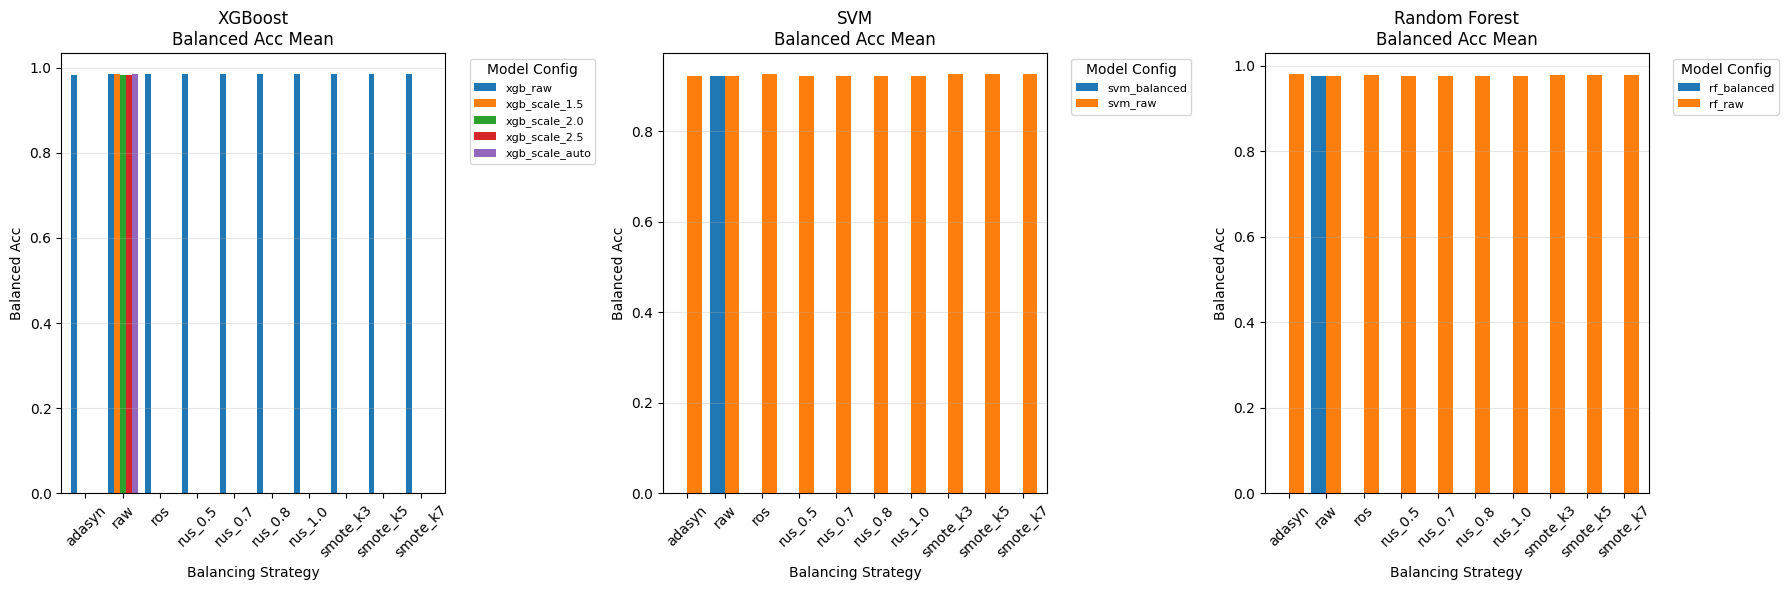

✓ Plot saved to: ../results/balancing_comparison/comparison_f1_mean.png


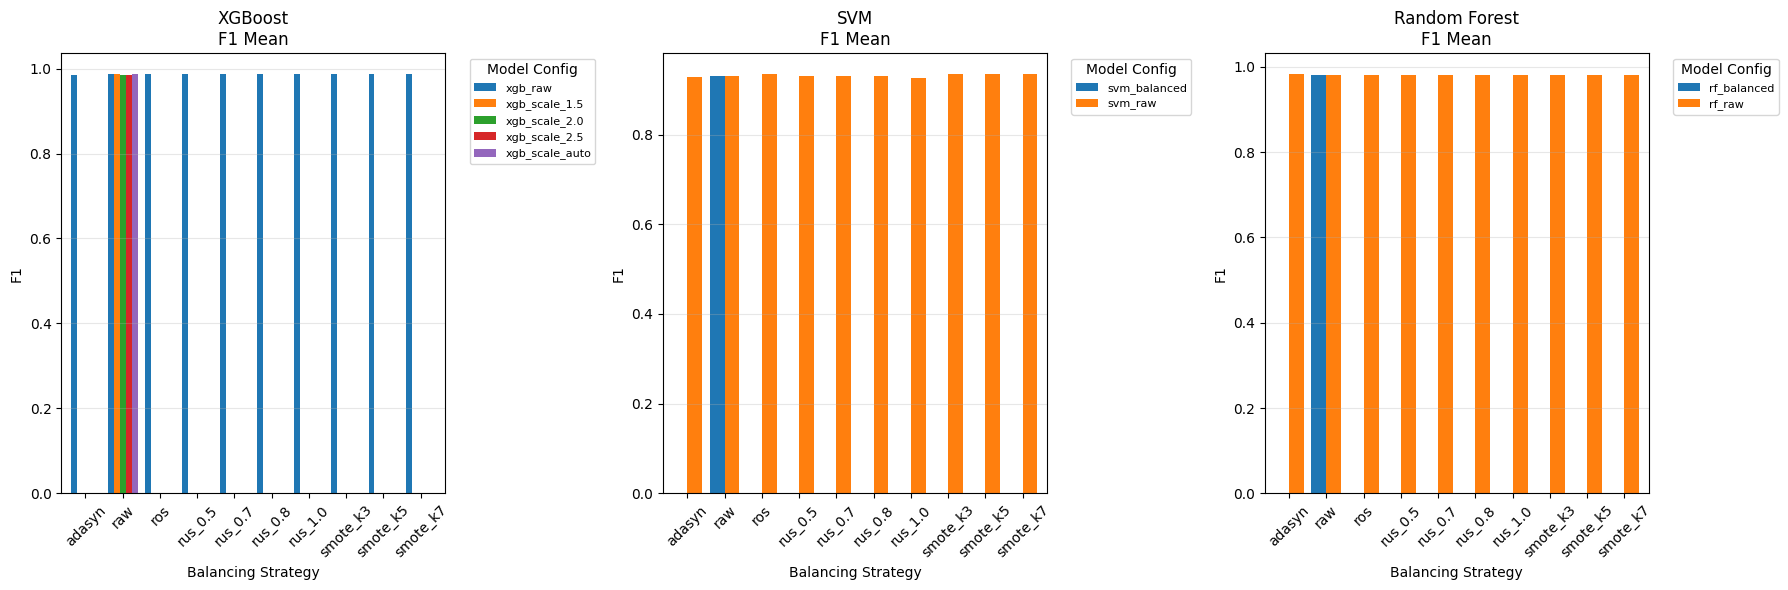

✓ Plot saved to: ../results/balancing_comparison/comparison_training_time_mean.png


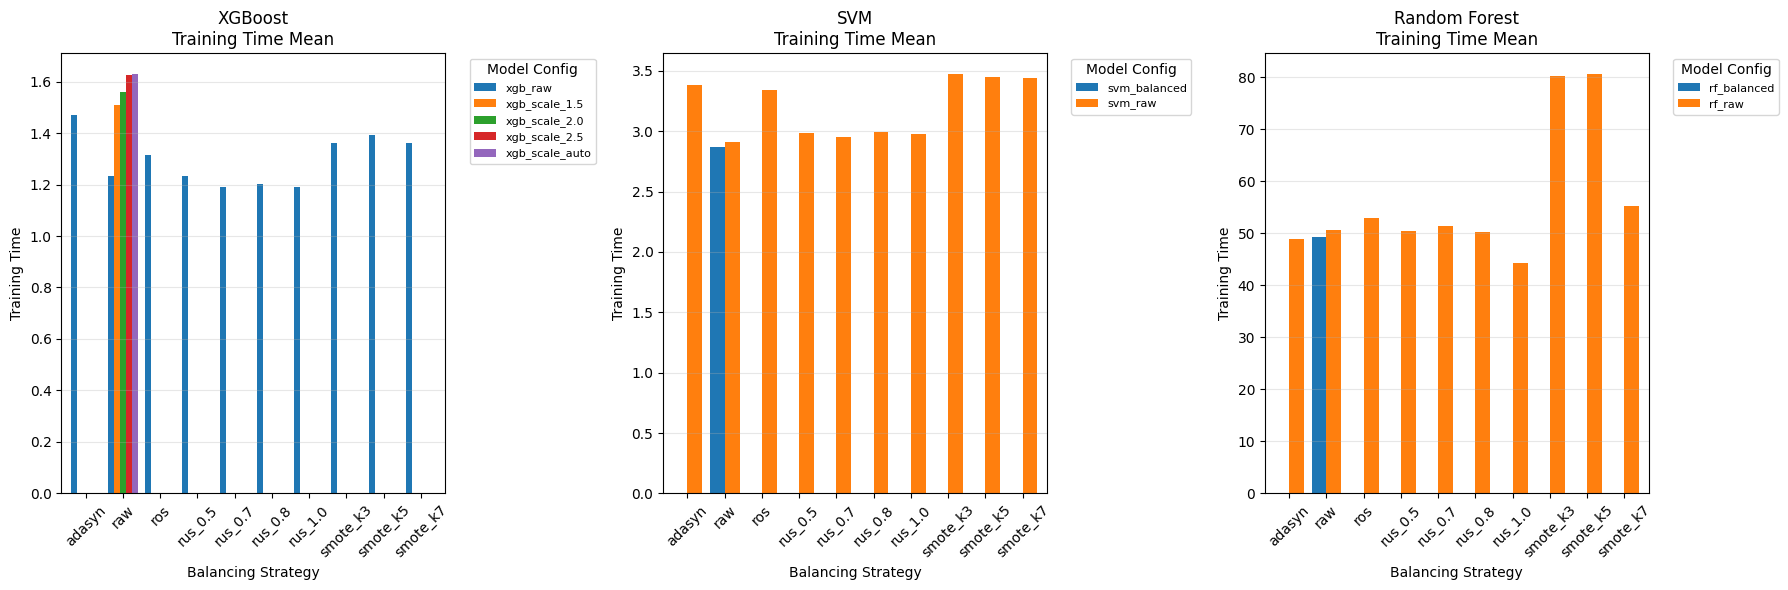


✓ All visualizations created


In [22]:
if FEAT_SET_TO_ANALYZE in all_results:
    results_df = all_results[FEAT_SET_TO_ANALYZE]
    
    # Plot balanced accuracy comparison
    print("Creating visualizations...\n")
    fig1 = plot_comparison(results_df, metric='balanced_acc_mean', figsize=(18, 6))
    plt.show()
    
    # Plot F1 score comparison
    fig2 = plot_comparison(results_df, metric='f1_mean', figsize=(18, 6))
    plt.show()
    
    # Plot training time comparison
    fig3 = plot_comparison(results_df, metric='training_time_mean', figsize=(18, 6))
    plt.show()
    
    print("\n✓ All visualizations created")

---
## Section 12: Statistical Significance Testing

In [23]:
if FEAT_SET_TO_ANALYZE in all_results:
    results_df = all_results[FEAT_SET_TO_ANALYZE]
    
    # Key comparisons to test
    print("\nKey Statistical Comparisons")
    print("="*80)
    
    # 1. XGBoost: scale_pos_weight vs SMOTE
    print("\n1. XGBoost: scale_pos_weight vs SMOTE")
    print("-"*80)
    result = compare_strategies_statistically(
        results_df, 'xgb_scale_2.0', 'raw', 'xgb_raw+smote_k5',
        metric='balanced_acc'
    )
    if 'error' not in result:
        print(f"XGBoost (scale_pos_weight=2.0): {result['mean_a']:.4f} ± {result['std_a']:.4f}")
        print(f"XGBoost (raw) + SMOTE_k5: Would need separate comparison")
        print(f"p-value: {result['p_value']:.6f}")
        print(f"Significant: {result['is_significant']}")
    
    # 2. SVM: class_weight vs SMOTE
    print("\n2. SVM: class_weight='balanced' vs SMOTE")
    print("-"*80)
    result = compare_strategies_statistically(
        results_df, 'svm_balanced', 'raw', 'svm_raw+smote_k5',
        metric='balanced_acc'
    )
    if 'error' not in result:
        print(f"SVM (class_weight='balanced'): {result['mean_a']:.4f} ± {result['std_a']:.4f}")
        print(f"SVM (raw) + SMOTE_k5: Would need separate comparison")
        print(f"p-value: {result['p_value']:.6f}")
        print(f"Significant: {result['is_significant']}")
    
    # 3. Run full pairwise comparison for XGBoost_raw
    print("\n3. XGBoost (raw) - All Balancing Strategies Comparison")
    print("-"*80)
    
    # Get available strategies for xgb_raw
    xgb_raw_strategies = results_df[results_df['model'] == 'xgb_raw']['balancing'].unique()
    
    if len(xgb_raw_strategies) > 1:
        comparison_df = run_pairwise_comparisons(
            results_df, 'xgb_raw', xgb_raw_strategies, metric='balanced_acc'
        )
        print_statistical_summary(comparison_df)
        
        # Save comparison results
        output_file = PATHS['results'] / f'statistical_comparisons_{FEAT_SET_TO_ANALYZE}.csv'
        comparison_df.to_csv(output_file, index=False)
        print(f"\n✓ Statistical comparison saved to: {output_file}")
    else:
        print("Not enough strategies to compare")


Key Statistical Comparisons

1. XGBoost: scale_pos_weight vs SMOTE
--------------------------------------------------------------------------------

2. SVM: class_weight='balanced' vs SMOTE
--------------------------------------------------------------------------------

3. XGBoost (raw) - All Balancing Strategies Comparison
--------------------------------------------------------------------------------


ValueError: zero_method 'wilcox' and 'pratt' do not work if x - y is zero for all elements.

---
## Section 13: Final Recommendations

In [24]:
if FEAT_SET_TO_ANALYZE in all_results:
    results_df = all_results[FEAT_SET_TO_ANALYZE]
    
    print("\nFinal Recommendations")
    print("="*80)
    
    # Find best overall configuration
    best_idx = results_df['balanced_acc_mean'].idxmax()
    best_config = results_df.loc[best_idx]
    
    print("\n🏆 BEST OVERALL CONFIGURATION:")
    print("-"*80)
    print(f"Model: {best_config['model']}")
    print(f"Balancing: {best_config['balancing']}")
    print(f"Feature Set: {best_config['feat_set']}")
    print(f"\nPerformance:")
    print(f"  Balanced Accuracy: {best_config['balanced_acc_mean']:.4f} ± {best_config['balanced_acc_std']:.4f}")
    print(f"  F1 Score:          {best_config['f1_mean']:.4f} ± {best_config['f1_std']:.4f}")
    print(f"  Recall (Grinder):  {best_config['recall_mean']:.4f} ± {best_config['recall_std']:.4f}")
    print(f"  Precision:         {best_config['precision_mean']:.4f} ± {best_config['precision_std']:.4f}")
    print(f"  Specificity:       {best_config['specificity_mean']:.4f} ± {best_config['specificity_std']:.4f}")
    print(f"  MCC:               {best_config['mcc_mean']:.4f} ± {best_config['mcc_std']:.4f}")
    print(f"  Training Time:     {best_config['training_time_mean']:.2f}s ± {best_config['training_time_std']:.2f}s")
    
    # Find best for each model type
    print("\n📊 BEST FOR EACH MODEL TYPE:")
    print("-"*80)
    
    for model_type in ['xgb', 'svm', 'rf']:
        model_results = results_df[results_df['model'].str.startswith(model_type)]
        if len(model_results) > 0:
            best_idx = model_results['balanced_acc_mean'].idxmax()
            best = model_results.loc[best_idx]
            print(f"\n{model_type.upper()}:")
            print(f"  Configuration: {best['model']} + {best['balancing']}")
            print(f"  Balanced Acc: {best['balanced_acc_mean']:.4f}, F1: {best['f1_mean']:.4f}, "
                  f"Recall: {best['recall_mean']:.4f}")
    
    # Deployment recommendations
    print("\n🚀 DEPLOYMENT RECOMMENDATIONS:")
    print("-"*80)
    
    # Filter for high recall (don't miss real threats)
    high_recall = results_df[results_df['recall_mean'] >= 0.90]
    
    if len(high_recall) > 0:
        # Among high recall, find best balanced accuracy
        deploy_idx = high_recall['balanced_acc_mean'].idxmax()
        deploy_config = high_recall.loc[deploy_idx]
        
        print("\nFor bike theft prevention (prioritizing recall ≥ 0.90):")
        print(f"  Recommended: {deploy_config['model']} + {deploy_config['balancing']}")
        print(f"  Balanced Acc: {deploy_config['balanced_acc_mean']:.4f}")
        print(f"  Recall: {deploy_config['recall_mean']:.4f} (won't miss {(1-deploy_config['recall_mean'])*100:.1f}% of real threats)")
        print(f"  Precision: {deploy_config['precision_mean']:.4f} (false alarm rate: {(1-deploy_config['precision_mean'])*100:.1f}%)")
        print(f"  Training Time: {deploy_config['training_time_mean']:.2f}s")
    else:
        print("\nNo configurations achieved recall ≥ 0.90")
        print("Consider:")
        print("  1. Adjusting class_weight or scale_pos_weight parameters")
        print("  2. Using more aggressive oversampling")
        print("  3. Collecting more grinder samples")
    
    print("\n" + "="*80)


Final Recommendations

🏆 BEST OVERALL CONFIGURATION:
--------------------------------------------------------------------------------
Model: xgb_scale_auto
Balancing: raw
Feature Set: mfcc

Performance:
  Balanced Accuracy: 0.9848 ± 0.0018
  F1 Score:          0.9869 ± 0.0016
  Recall (Grinder):  0.9938 ± 0.0018
  Precision:         0.9802 ± 0.0016
  Specificity:       0.9758 ± 0.0019
  MCC:               0.9711 ± 0.0035
  Training Time:     1.63s ± 0.02s

📊 BEST FOR EACH MODEL TYPE:
--------------------------------------------------------------------------------

XGB:
  Configuration: xgb_scale_auto + raw
  Balanced Acc: 0.9848, F1: 0.9869, Recall: 0.9938

SVM:
  Configuration: svm_raw + smote_k5
  Balanced Acc: 0.9258, F1: 0.9349, Recall: 0.9484

RF:
  Configuration: rf_raw + adasyn
  Balanced Acc: 0.9802, F1: 0.9828, Recall: 0.9897

🚀 DEPLOYMENT RECOMMENDATIONS:
--------------------------------------------------------------------------------

For bike theft prevention (prioritizing

---
## Section 14: Export Summary Report

In [ ]:
if FEAT_SET_TO_ANALYZE in all_results:
    results_df = all_results[FEAT_SET_TO_ANALYZE]
    
    # Create comprehensive summary
    summary_cols = [
        'model', 'balancing', 'feat_set',
        'balanced_acc_mean', 'balanced_acc_std',
        'f1_mean', 'f1_std',
        'recall_mean', 'recall_std',
        'precision_mean', 'precision_std',
        'specificity_mean', 'specificity_std',
        'mcc_mean', 'mcc_std',
        'pr_auc_mean', 'pr_auc_std',
        'training_time_mean', 'training_time_std',
        'samples_after_balancing_mean'
    ]
    
    summary_df = results_df[summary_cols].sort_values('balanced_acc_mean', ascending=False)
    
    # Save detailed summary
    output_file = PATHS['results'] / f'detailed_summary_{FEAT_SET_TO_ANALYZE}.csv'
    summary_df.to_csv(output_file, index=False)
    print(f"✓ Detailed summary saved to: {output_file}")
    
    # Create LaTeX table for paper/report
    top_5 = summary_df.head(5)[[
        'model', 'balancing', 'balanced_acc_mean', 'f1_mean', 
        'recall_mean', 'precision_mean'
    ]]
    
    latex_output = PATHS['results'] / f'top5_table_{FEAT_SET_TO_ANALYZE}.tex'
    with open(latex_output, 'w') as f:
        f.write(top_5.to_latex(index=False, float_format="%.4f"))
    print(f"✓ LaTeX table saved to: {latex_output}")
    
    print("\n✓ All reports generated successfully!")

---
## Conclusion

This notebook provides a comprehensive evaluation of class imbalance handling strategies for angle grinder detection. 

### Key Takeaways:
1. Compare 7+ balancing strategies systematically
2. Test across 3 model types (XGBoost, SVM, Random Forest)
3. Use proper stratified cross-validation
4. Evaluate with multiple metrics appropriate for imbalanced data
5. Statistical significance testing to confirm differences
6. Clear recommendations for deployment

### Next Steps:
- Run experiments on remaining feature sets ('gtcc', 'combined')
- Test winning configurations on held-out test set
- Implement best strategy in main training pipeline (notebook 05)
- Consider hyperparameter tuning for top configurations